In [119]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
def print_stats(r2_1, mse_1, thresholds=[0.5, 0.8]):
    r2_1, mse_1 = np.array(r2_1), np.array(mse_1)

    def summary_stats(metric):
        return (np.nanmean(metric), np.nanmedian(metric), np.nanmax(metric), np.nanmin(metric))

    r2_1_stats = summary_stats(r2_1)
    mse_1_stats = summary_stats(mse_1)

    
    print(f"Model 1 R²: Mean={r2_1_stats[0]:.4f}, Median={r2_1_stats[1]:.4f}, Max={r2_1_stats[2]:.4f}, Min={r2_1_stats[3]:.4f}")

    print(f"Model 1 MSE: Mean={mse_1_stats[0]:.2e}, Median={mse_1_stats[1]:.2e}, Max={mse_1_stats[2]:.2e}, Min={mse_1_stats[3]:.2e}")

    for t in thresholds:
        count1 = np.sum(r2_1 > t)
        print(f"Signatures with R² > {t}: {count1}")
    print()

In [121]:
class PredictExposureWith0Sensitivity:
    def __init__(self, model):
        self.model = model

    def fit(self, X_train, y_bin_train, y_exp_train):
        regressors = []
        for i in range(y_bin_train.shape[1]):       # for each of the 29 binarized label
            idx_train = y_bin_train[:, i] == 1  # if the signature for that sample i 0 do not use it for training the regressor on that signature
            if not np.any(idx_train):
                regressors.append(None)
                continue
            y_train_i = y_exp_train[idx_train, i]

            model_i = clone(self.model)
            model_i.fit(X_train[idx_train], y_train_i)
            regressors.append(model_i)
        return regressors

    def evaluate(self, regressors, X_test, y_bin_test, y_exp_test):
        r2_scores = []
        mse_scores = []
        predictions = []

        for i, model_i in enumerate(regressors):
            y_pred_i = np.zeros(y_bin_test.shape[0])
            idx_test = y_bin_test[:, i] == 1

            if model_i is not None and np.any(idx_test):
                y_pred_i[idx_test] = model_i.predict(X_test[idx_test])

                y_test_i = y_exp_test[idx_test, i]
                r2_scores.append(r2_score(y_test_i, y_pred_i[idx_test]))
                mse_scores.append(mean_squared_error(y_test_i, y_pred_i[idx_test]))
            else:
                r2_scores.append(np.nan)
                mse_scores.append(np.nan)

            predictions.append(y_pred_i)

        return r2_scores, mse_scores, predictions


In [122]:
class PredictExposureAllSamples:
    def __init__(self, model):
        self.model = model

    def fit(self, X_train, y_exp_train):
        self.regressors = []
        for i in range(y_exp_train.shape[1]):
            y_train_i = y_exp_train[:, i]
            model_i = clone(self.model)
            model_i.fit(X_train, y_train_i)
            self.regressors.append(model_i)
        return self.regressors

    def evaluate(self, X_test, y_exp_test):
        r2_scores = []
        mse_scores = []
        predictions = []

        for i, model_i in enumerate(self.regressors):
            y_pred_i = model_i.predict(X_test)
            y_test_i = y_exp_test[:, i]

            r2_scores.append(r2_score(y_test_i, y_pred_i))
            mse_scores.append(mean_squared_error(y_test_i, y_pred_i))
            predictions.append(y_pred_i)

        return r2_scores, mse_scores, predictions


### Prediction with the LightGBMXT model

In [123]:
# predictor = MultilabelPredictor.load('../models/saved/Predictor-0.03')
# new_base_path = '../models/saved/Predictor-0.03'
# pred_mutation_count = pd.read_csv('../simulations/data2/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:,1:]
# # aggiorna i path per ogni label
# for label in predictor.labels:
#     predictor.predictors[label] = os.path.join(new_base_path, f'Predictor_{label}')
    
# prediction = predictor.predict(pred_mutation_count)

## Prediction with the GT

### Split train and test Data

train feature data:
- 96 values indicating the mutation count for each type of mutation
- 29 binary labels

train target data:
- 29 real numbers indicating the exposure value 

In [ ]:
seed = np.random.randint(1,100000)
np.random.seed(seed=seed)
train_size = 0.8
# Loading the data
signature_prob_distribution = pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:,1:].values
mutation_count = pd.read_csv('../simulations/data/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:,1:].values  # N x 96
mutation_count_bin = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:,1:].astype(int).values  # N x 29

signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:,1:].values  # N x 29
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

In [125]:
signatures = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').columns[1:]

### Simple Linear Regressor

In [126]:
pes_0 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_0.fit(X_train, y_bin_train, y_exp_train)
r2_0,mse_0,pred_0 = pes_0.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [127]:
print_stats(r2_0,mse_0)

Model 1 R²: Mean=0.8025, Median=0.8991, Max=0.9975, Min=0.1803
Model 1 MSE: Mean=2.24e+07, Median=3.13e+06, Max=3.21e+08, Min=1.25e+05
Signatures with R² > 0.5: 25
Signatures with R² > 0.8: 18



In [132]:
r2s, mses = [], []
results = []

for i in range(100):
    print(f'{i}/{100} - {i}%', end='\r')
    seed = np.random.randint(1, 100000)
    X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
        mutation_count, mutation_count_bin, signature_exposure, random_state=seed, train_size=train_size,
    )
    model = PredictExposureWith0Sensitivity(LinearRegression())
    regressors = model.fit(X_train, y_bin_train, y_exp_train)
    r2, mse, pred = model.evaluate(regressors, X_test, y_bin_test, y_exp_test)
    # Indici e nomi per max/min R²
    r2_max_idx = np.argmax(r2)
    r2_min_idx = np.argmin(r2)

    # Indici e nomi per max/min MSE
    mse_max_idx = np.argmax(mse)
    mse_min_idx = np.argmin(mse)
    results.append({
        "seed": seed,
        "average R^2": np.mean(r2),
        "average MSE": np.mean(mse),
        "R^2 max name": signatures[r2_max_idx],
        "R^2 max value": r2[r2_max_idx],
        "R^2 min name": signatures[r2_min_idx],
        "R^2 min value": r2[r2_min_idx],
        "MSE max name": signatures[mse_max_idx],
        "MSE max value": mse[mse_max_idx],
        "MSE min name": signatures[mse_min_idx],
        "MSE min value": mse[mse_min_idx],
    })

df = pd.DataFrame(results)
df.to_csv('./no_prepocessing.csv')


In [ ]:
pes = PredictExposureAllSamples(LinearRegression())
regressors = pes.fit(X_train, y_exp_train)
r2,mse,pred = pes.evaluate(X_test, y_exp_test)

In [ ]:
print_stats(r2,mse)

Model 1 R²: Mean=0.5155, Median=0.6548, Max=0.9994, Min=-2.6154
Model 1 MSE: Mean=4.58e+06, Median=1.68e+06, Max=3.38e+07, Min=1.36e+05
Signatures with R² > 0.5: 18
Signatures with R² > 0.8: 11



In [130]:
r2s, mses = [], []
results = []

for i in range(100):
    print(f'{i}/{500} - {i/500*100}%', end='\r')
    seed = np.random.randint(1, 100000)
    X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
        mutation_count, mutation_count_bin, signature_exposure, random_state=seed, train_size=train_size,
    )
    model = PredictExposureAllSamples(LinearRegression())
    regressors = model.fit(X_train, y_exp_train)
    r2, mse, pred = model.evaluate(X_test, y_exp_test)
    # Indici e nomi per max/min R²
    r2_max_idx = np.argmax(r2)
    r2_min_idx = np.argmin(r2)

    # Indici e nomi per max/min MSE
    mse_max_idx = np.argmax(mse)
    mse_min_idx = np.argmin(mse)
    results.append({
        "seed": seed,
        "average R^2": np.mean(r2),
        "average MSE": np.mean(mse),
        "R^2 max name": signatures[r2_max_idx],
        "R^2 max value": r2[r2_max_idx],
        "R^2 min name": signatures[r2_min_idx],
        "R^2 min value": r2[r2_min_idx],
        "MSE max name": signatures[mse_max_idx],
        "MSE max value": mse[mse_max_idx],
        "MSE min name": signatures[mse_min_idx],
        "MSE min value": mse[mse_min_idx],
    })

df = pd.DataFrame(results)
df.to_csv('./all_dataset.csv')


KeyboardInterrupt: 

<Axes: ylabel='average R^2'>

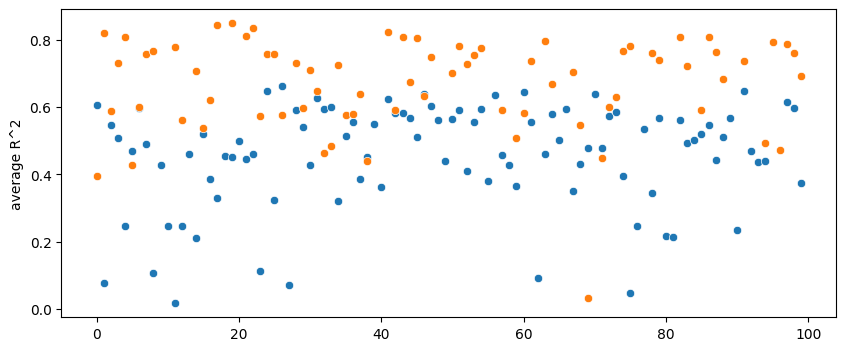

In [ ]:
df_all = pd.read_csv('./all_dataset.csv')
df_noprep = pd.read_csv('./no_prepocessing.csv').iloc[:100, :]

# Scatterplot solo per valori R² > 0
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_all[df_all['average R^2'] > 0]['average R^2'])
sns.scatterplot(data=df_noprep[df_noprep['average R^2'] > 0]['average R^2'])

plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_all[df_all['average R^2'] <= 0]['average R^2'])
sns.scatterplot(data=df_noprep[df_noprep['average R^2'] <= 0]['average R^2'])


In [252]:
df = pd.read_csv('./no_prepocessing.csv')
# Conta le occorrenze di ogni stringa
# Conta le occorrenze
r2_counts = df['R^2 min name'].value_counts()
mse_counts = df['MSE max name'].value_counts()

print(r2_counts)
print(mse_counts)

# # SCATTERPLOT per R² min name
# plt.figure(figsize=(10, 4))
# sns.scatterplot(x=r2_counts.index, y=r2_counts.values)
# plt.title("Frequenza R² minimo per signature")
# plt.ylabel("Frequenza")
# plt.xlabel("Signature")
# plt.xticks(rotation=45, ha='right')  # 👈 inclinazione etichette
# plt.tight_layout()
# plt.show()

# # SCATTERPLOT per MSE min name
# plt.figure(figsize=(10, 8))
# sns.scatterplot(x=mse_counts.index, y=mse_counts.values)
# plt.title("Frequenza MSE massimo per signature")
# plt.ylabel("Frequenza")
# plt.xlabel("Signature")
# plt.xticks(rotation=45, ha='right')  # 👈 inclinazione etichette
# plt.tight_layout()
# plt.show()


R^2 min name
S24 (SBS31 - 0.98)     150
S18 (SBS19 - 0.95)      68
S27 (SBS88 - 0.92)      61
S25 (SBS32 - 0.94)      40
S8 (SBS8 - 0.92)        36
S23 (SBS28 - 0.96)      31
S3 (SBS3 - 0.97)        25
S28 (SBS92 - 0.95)      20
S21 (SBS23 - 0.94)      20
S17 (SBS18 - 0.97)      12
S20 (SBS22 - 0.99)      12
S12 (SBS11 - 0.99)       7
S5 (SBS5 - 0.98)         4
S16 (SBS17 - 0.99)       4
S15 (SBS15 - 0.97)       2
S9 (SBS9 - 0.94)         2
S19 (SBS20 - 0.98)       2
S29 (SBS97 - 0.95)       2
S14 (SBS14 - 0.98)       1
S11 (SBS10d - 0.98)      1
Name: count, dtype: int64
MSE max name
S14 (SBS14 - 0.98)    274
S19 (SBS20 - 0.98)    105
S24 (SBS31 - 0.98)     73
S23 (SBS28 - 0.96)     42
S9 (SBS9 - 0.94)        2
S12 (SBS11 - 0.99)      1
S22 (SBS26 - 0.94)      1
S27 (SBS88 - 0.92)      1
S8 (SBS8 - 0.92)        1
Name: count, dtype: int64


## Data preprocessing

### Outlier removal

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

seed = np.random.randint(1, 100000)
#np.random.seed(seed=50)
train_size = 0.8

# Caricamento dati
signature_prob_distribution = pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:, 1:].values
mutation_count = pd.read_csv('../simulations/data/run_1/trinucleotides_counts_sampling_0.03.csv').iloc[:, 1:].values  # N x 96
mutation_count_bin = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:, 1:].astype(int).values  # N x 29
signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].values  # N x 29

# Rimozione outlier su y_exp_train (signature-wise IQR)
def remove_outliers_iqr(X, y_bin, y_exp, threshold=1.5, max_outlier_signatures=4):
    keep_mask = np.ones(len(y_exp), dtype=bool)
    outlier_count = np.zeros(len(y_exp), dtype=int)

    for col in range(y_exp.shape[1]):
        q1 = np.percentile(y_exp[:, col], 25)
        q3 = np.percentile(y_exp[:, col], 75)
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr

        # conta se il sample è outlier in questa signature
        outlier_col = (y_exp[:, col] < lower) | (y_exp[:, col] > upper)
        outlier_count += outlier_col.astype(int)

    # rimuovi solo quelli che sono outlier in troppe signature
    keep_mask = outlier_count <= max_outlier_signatures
    return X[keep_mask], y_bin[keep_mask], y_exp[keep_mask]


def balance_dataset(X, y_bin, y_exp):
    indices_to_keep = []

    for i in range(y_bin.shape[1]):  # per ogni signature
        pos_idx = np.where(y_bin[:, i] == 1)[0]
        neg_idx = np.where(y_bin[:, i] == 0)[0]

        if len(pos_idx) == 0 or len(neg_idx) == 0:
            continue  # ignora le signature completamente nulle o completamente attive

        # sottocampiona negativi per pareggiare i positivi
        neg_sampled = np.random.choice(neg_idx, size=len(pos_idx), replace=True)
        balanced_idx = np.concatenate([pos_idx, neg_sampled])
        indices_to_keep.extend(balanced_idx)

    # Rimuove duplicati (alcuni sample possono comparire in più signature)
    indices_to_keep = np.unique(indices_to_keep)
    
    return X[indices_to_keep], y_bin[indices_to_keep], y_exp[indices_to_keep]

array([17453, 15444, 10852,  9929, 12426, 14014,  5526,  7951,  7355,
        6710,  7160,  3784, 13978,  4250,  7047,  8212, 10540,  6208,
         925,  7476,  3059,  3701,  4140,  1856,  5371,  6222, 11845,
       12566,  4384])

In [237]:
seed = np.random.randint(1, 100000)
np.random.seed(seed=seed)
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
    mutation_count, mutation_count_bin, signature_exposure, train_size=train_size,
)
x = pd.DataFrame({
    "total_in_dataset": np.sum(mutation_count_bin, axis=0),
    "total_in_train": np.sum(y_bin_train, axis=0)
})
x["dataset/train_ratio"] = x["total_in_train"] / x["total_in_dataset"]
x

,total_in_dataset,total_in_train,dataset/train_ratio
0,17453,13959,0.799805
1,15444,12368,0.800829
2,10852,8725,0.803999
3,9929,7970,0.802699
4,12426,9930,0.799131
5,14014,11204,0.799486
6,5526,4449,0.805103
7,7951,6356,0.799396
8,7355,5882,0.799728
9,6710,5385,0.802534


In [83]:
r2s, mses = [], []
results = []

for i in range(100):
    seed = np.random.randint(1, 100000)
    X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
        mutation_count, mutation_count_bin, signature_exposure, random_state=seed, train_size=train_size,
    )
    
    # Applica rimozione outlier prima
    X_train, y_bin_train, y_exp_train = remove_outliers_iqr(X_train, y_bin_train, y_exp_train)

    # Poi bilancia il dataset
    X_train, y_bin_train, y_exp_train = balance_dataset(X_train, y_bin_train, y_exp_train)
    
    model = PredictExposureWith0Sensitivity(LinearRegression())
    regressors = model.fit(X_train, y_bin_train, y_exp_train)
    r2, mse, pred = model.evaluate(regressors, X_test, y_bin_test, y_exp_test)
    
    # Indici e nomi per max/min R²
    r2_max_idx = np.argmax(r2)
    r2_min_idx = np.argmin(r2)

    # Indici e nomi per max/min MSE
    mse_max_idx = np.argmax(mse)
    mse_min_idx = np.argmin(mse)
    results.append({
        "seed": seed,
        "average R^2": np.mean(r2),
        "average MSE": np.mean(mse),
        "R^2 max name": signatures[r2_max_idx],
        "R^2 max value": r2[r2_max_idx],
        "R^2 min name": signatures[r2_min_idx],
        "R^2 min value": r2[r2_min_idx],
        "MSE max name": signatures[mse_max_idx],
        "MSE max value": mse[mse_max_idx],
        "MSE min name": signatures[mse_min_idx],
        "MSE min value": mse[mse_min_idx],
    })

df = pd.DataFrame(results)
df.to_csv('./prepocessing.csv')


<Axes: ylabel='average MSE'>

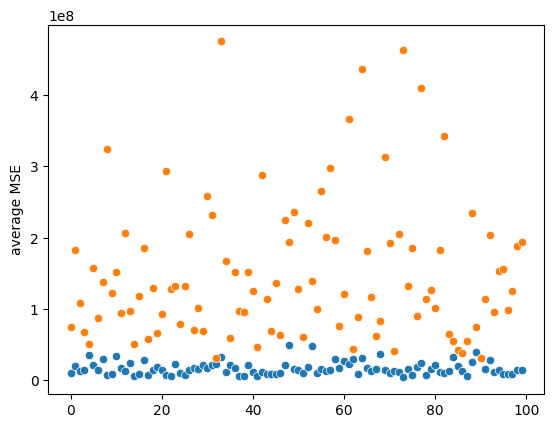

In [95]:
no_prep = pd.read_csv('no_prepocessing.csv').iloc[:100,:]
sns.scatterplot(no_prep['average MSE'])
prep = pd.read_csv('prepocessing.csv')
sns.scatterplot(prep['average MSE'])

## Other models

### Simple linear Regressor with the mutation count accounted for the signature probability distribution

In [33]:
signature_exposure = pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:,1:].values  # N x 29
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            mutation_count @ signature_prob_distribution.T, mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

In [34]:
pes_2 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_2.fit(X_train, y_bin_train, y_exp_train)
r2_2,mse_2,pred_2 = pes_2.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [35]:
print_stats(r2_2,mse_2)

Model 1 R²: Mean=-0.4466, Median=0.8472, Max=0.9988, Min=-17.0993
Model 1 MSE: Mean=2.61e+07, Median=4.68e+06, Max=2.25e+08, Min=4.27e+04
Signatures with R² > 0.5: 22
Signatures with R² > 0.8: 19



### ElasticNet

In [36]:
from sklearn.linear_model import ElasticNet
pes_2 = PredictExposureWith0Sensitivity(ElasticNet(random_state=seed))
regressors = pes_2.fit(X_train, y_bin_train, y_exp_train)
r2_2,mse_2,pred_2 = pes_2.evaluate(regressors, X_test, y_bin_test, y_exp_test)

/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.806e+10, tolerance: 8.169e+07
  model = cd_fast.enet_coordinate_descent(
/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.326e+09, tolerance: 2.962e+07
  model = cd_fast.enet_coordinate_descent(
/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the

In [37]:
print_stats(r2_2,mse_2)

Model 1 R²: Mean=-1.7798, Median=0.8112, Max=0.9964, Min=-71.9031
Model 1 MSE: Mean=4.85e+07, Median=7.30e+06, Max=7.51e+08, Min=3.34e+04
Signatures with R² > 0.5: 25
Signatures with R² > 0.8: 15



### Simple linear Regressor with the mutation count accounted for the signature probability distribution and tissue sample

In [845]:
from sklearn.preprocessing import LabelEncoder
tissues = pd.read_csv('../simulations/ground_truth/tumor_site.csv').iloc[:,1:-1].values
encoder = LabelEncoder()
tissues_encoded = pd.DataFrame(encoder.fit_transform(tissues))

/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [846]:
X_train, X_test, y_bin_train, y_bin_test, y_exp_train, y_exp_test = train_test_split(
            np.hstack([mutation_count @ signature_prob_distribution.T,tissues_encoded]), mutation_count_bin, signature_exposure, random_state = seed, train_size=train_size,
        )

In [847]:
pes_3 = PredictExposureWith0Sensitivity(LinearRegression())
regressors = pes_3.fit(X_train, y_bin_train, y_exp_train)
r2_3,mse_3,pred_3 = pes_3.evaluate(regressors, X_test, y_bin_test, y_exp_test)

In [848]:
print_stats(r2_3, mse_3)

Model 1 R²: Mean=0.8262, Median=0.9003, Max=0.9993, Min=-0.2590
Model 1 MSE: Mean=3.65e+06, Median=1.13e+06, Max=3.17e+07, Min=7.98e+04
Signatures with R² > 0.5: 27
Signatures with R² > 0.8: 20



In [849]:
seed
# 8070

66405